In [1]:
# tumor_prop.ipynb - plot proportions of tumor and other cell types.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data_fn = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/analysis/base/tumor_prop/tumor_prop.tsv"
out_fig = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1r1n1t/vary_tumor_prop/analysis/base/tumor_prop/tumor_prop.png"
dpi = 300

In [4]:
df = pd.read_csv(data_fn, sep = '\t')
df

,tumor_perc,n_ref,n_normal,n_tumor
0,1,600,990,10
1,3,600,970,30
2,10,600,900,100
3,30,600,700,300
4,50,600,500,500
5,70,600,300,700
6,90,600,100,900
7,97,600,30,970
8,99,600,10,990


In [5]:
# Sort by tumor_perc if needed
df = df.sort_values('tumor_perc').reset_index(drop = True)
df['run_id'] = df['tumor_perc'].map(lambda x: str(x))
df

,tumor_perc,n_ref,n_normal,n_tumor,run_id
0,1,600,990,10,1
1,3,600,970,30,3
2,10,600,900,100,10
3,30,600,700,300,30
4,50,600,500,500,50
5,70,600,300,700,70
6,90,600,100,900,90
7,97,600,30,970,97
8,99,600,10,990,99


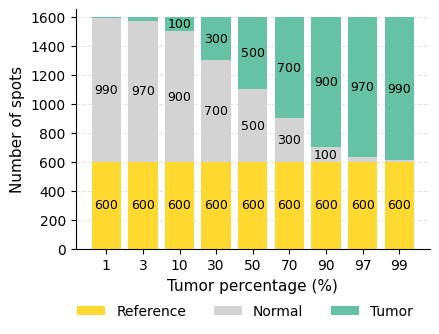

In [6]:
# Create figure and axis
fig, ax = plt.subplots(figsize = (4.5, 3.5))

# X positions for bars
x = np.arange(len(df))
bar_width = 0.8

# Stack bars from bottom to top: n_ref, n_normal, n_tumor
bottom = np.zeros(len(df))

# Color scheme (you can customize)
cmap = plt.get_cmap("Set2")
colors = [
    cmap(5), 
    'lightgrey',
    cmap(0)
]
labels = ['Reference', 'Normal', 'Tumor']
columns = ['n_ref', 'n_normal', 'n_tumor']

# Plot each stack
bars_list = []
for i, (col, color, label) in enumerate(zip(columns, colors, labels)):
    bars = ax.bar(x, df[col], bottom = bottom, width = bar_width, 
                  color = color, label = label, linewidth = 0.5)
    bars_list.append(bars)
    
    # Add text labels on each stack
    for j, (rect, val) in enumerate(zip(bars, df[col])):
        if val >= 100:        # Only show label if value > 0
            ax.text(rect.get_x() + rect.get_width()/2, 
                   bottom[j] + val/2, 
                   f'{int(val)}', 
                   ha = 'center', va = 'center', 
                   fontsize = 9, color = 'black')
    
    bottom += df[col].values

# Customize the plot
ax.set_xlabel('Tumor percentage (%)', fontsize = 11)
ax.set_ylabel('Number of spots', fontsize = 11)
ax.set_xticks(x)
ax.set_ylim(0, 1650)
ax.set_yticks([0, 200, 400, 600, 800, 1000, 1200, 1400, 1600])
ax.set_xticklabels(df['run_id'])
ax.legend(loc='upper left', bbox_to_anchor = (-0.03, -0.18), frameon = False, ncol = 3)
ax.grid(axis = 'y', alpha = 0.3, linestyle = '--')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent legend cutoff
plt.tight_layout()
fig.savefig(out_fig, dpi = 300, bbox_inches = 'tight')